In [5]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.stats import sigma_clipped_stats

from astropy.convolution import convolve
from photutils.segmentation import make_2dgaussian_kernel
from scipy import ndimage
from matplotlib.patches import Ellipse

In [6]:
images = [
    '../src/barred_galaxies/strongly_barred/phys_src_00173.fits', 
    '../src/barred_galaxies/strongly_barred/phys_src_00243.fits',
    '../src/barred_galaxies/strongly_barred/phys_src_00352.fits',
    '../src/barred_galaxies/strongly_barred/phys_src_00706.fits',
    '../src/barred_galaxies/strongly_barred/phys_src_00188.fits',
    '../src/barred_galaxies/strongly_barred/phys_src_00211.fits',
    '../src/barred_galaxies/strongly_barred/phys_src_00304.fits',
    '../src/barred_galaxies/strongly_barred/phys_src_00151.fits',
    '../src/barred_galaxies/weakly_barred/phys_src_00611.fits',
    '../src/barred_galaxies/weakly_barred/phys_src_00027.fits',
    '../src/barred_galaxies/weakly_barred/phys_src_00037.fits',
    '../src/barred_galaxies/weakly_barred/phys_src_00597.fits',
    '../src/barred_galaxies/weakly_barred/phys_src_01310.fits',
    '../src/barred_galaxies/weakly_barred/phys_src_01426.fits',
    '../src/barred_galaxies/weakly_barred/phys_src_00177.fits',
]

In [9]:
convs = []
conv_subs = []

for image in images: 
    file = fits.open(image)
    sci = file["SCI"].data.astype(float)
    err = file["ERR"].data.astype(float)

    mean, sky_median, sky_std = sigma_clipped_stats(sci, sigma=3.0)

    # Gentle smoothing (preserves bar ends) used for the mask & fit
    kernel_light = make_2dgaussian_kernel(1.5, size=5)
    
    conv = convolve(sci, kernel_light)
    convs.append(conv)
    
    # Sky stats computed on the smoothed image (self-consistent subtraction)
    _, sky_median_conv, sky_std_conv = sigma_clipped_stats(conv, sigma=3.0)
    
    conv_sub = conv - sky_median_conv
    conv_subs.append(conv_sub)

In [13]:
if len(images) % 4 == 0:
    rows = len(images) // 4
else:
    rows = (len(images) // 4) + 1
columns = 4

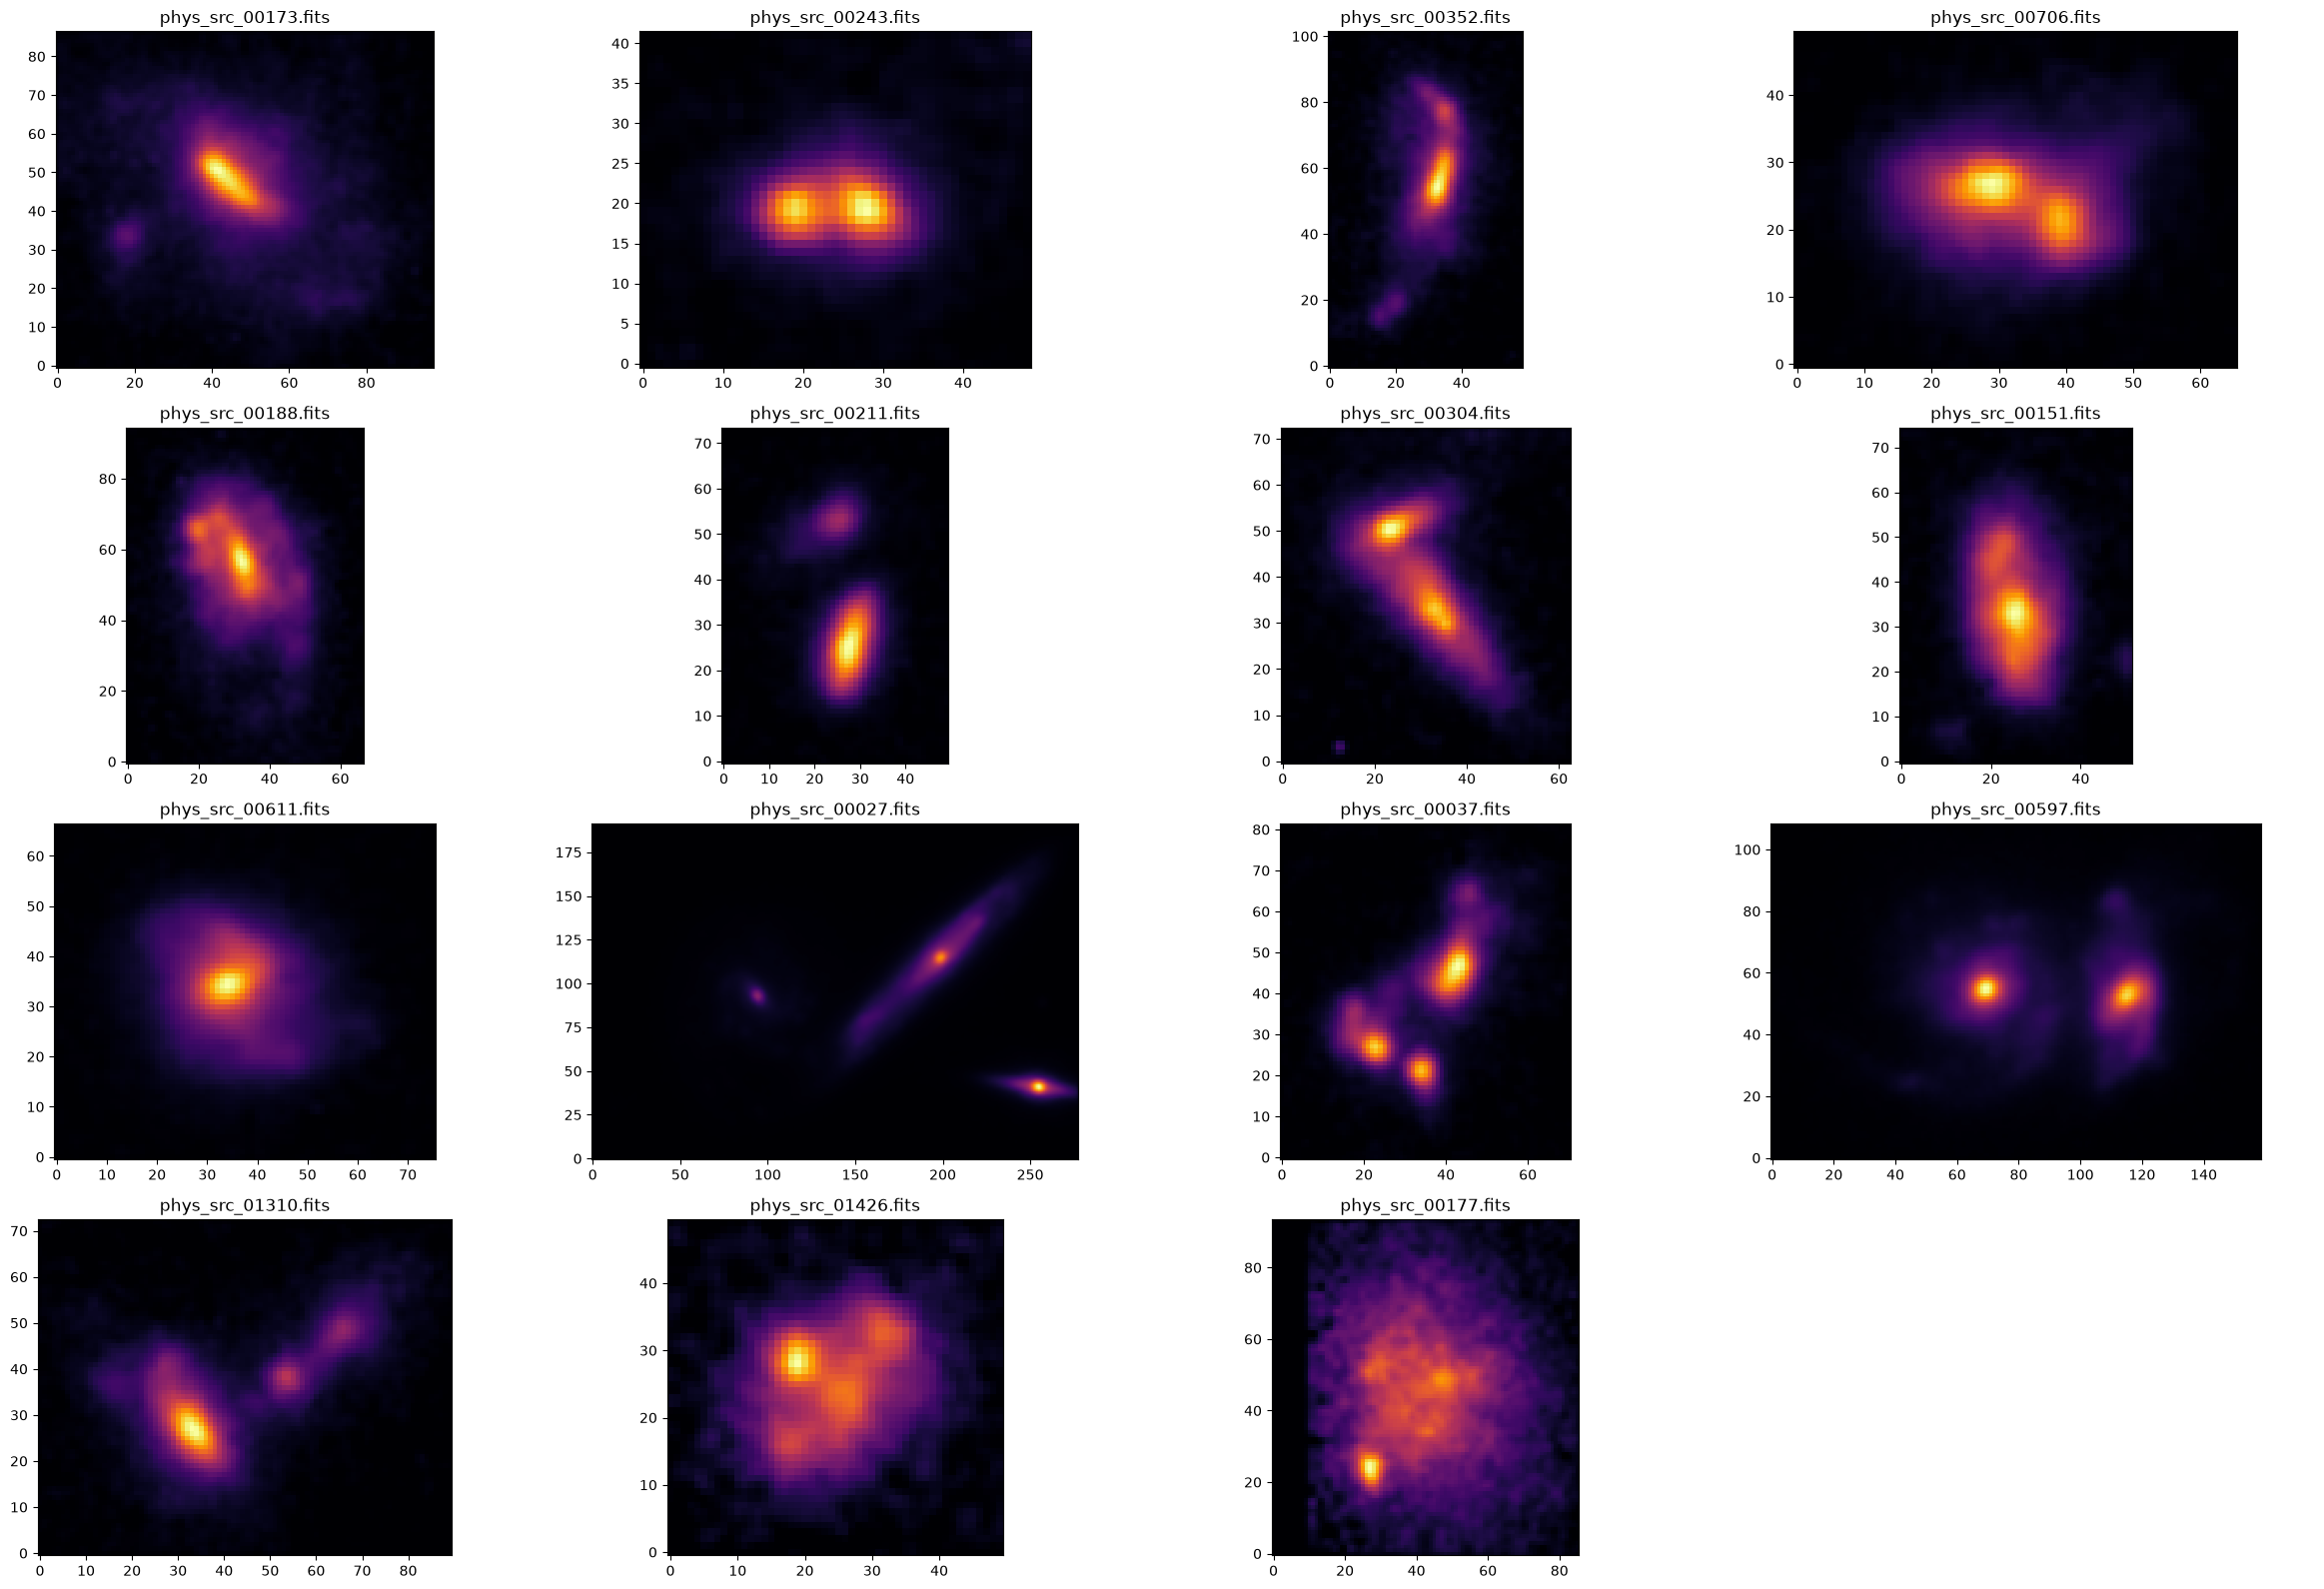

In [18]:
fig, axes = plt.subplots(rows, columns, figsize=(24, 16), squeeze=False)

for i, ax_i in enumerate(axes.flat):
    if i < len(convs):
        ax_i.imshow(convs[i], origin="lower", cmap="inferno",
                    vmin=0, vmax=convs[i].max())
        ax_i.set_title(images[i].split("/")[-1])
    else:
        ax_i.axis("off")

plt.tight_layout()
plt.show()

In [19]:
from scipy.ndimage import (
    binary_closing,
    generate_binary_structure,
    label as nd_label,
    center_of_mass,
    sum as nd_sum,
)

def measure_bar_ellipse(conv, conv_sub):
    """Return the threshold mask, moment ellipse, and preliminary bar flag."""

    # Estimate the noise in the smoothed image.
    _, _, sky_std = sigma_clipped_stats(conv, sigma=3.0)

    peak = np.nanmax(conv_sub)
    if not np.isfinite(peak) or peak <= 0:
        return {"mask": np.zeros_like(conv_sub, dtype=bool)}

    # Keep pixels above both the noise and relative-brightness cutoffs.
    threshold = max(3.0 * sky_std, 0.53 * peak)
    binary = conv_sub > threshold

    # Fill small gaps and label connected bright regions.
    structure = generate_binary_structure(2, 2)
    binary = binary_closing(binary, structure=structure, iterations=1)
    labels, n_labels = nd_label(binary, structure=structure)

    if n_labels == 0:
        return {"mask": binary}

    # Keep the largest region plus nearby smaller regions.
    if n_labels > 1:
        sizes = nd_sum(binary, labels, range(1, n_labels + 1))
        largest = int(np.argmax(sizes)) + 1
        cy, cx = center_of_mass(binary, labels, largest)
        r_keep = 1.5 * np.sqrt(sizes[largest - 1] / np.pi)

        keep = [largest]
        for label_id in range(1, n_labels + 1):
            if label_id == largest or sizes[label_id - 1] < 3:
                continue

            yi, xi = center_of_mass(binary, labels, label_id)
            if np.hypot(yi - cy, xi - cx) < r_keep:
                keep.append(label_id)

        binary = np.isin(labels, keep)

    n_mask_pix = int(binary.sum())
    r_eq = float(np.sqrt(n_mask_pix / np.pi))

    # Skip masks too small for a useful ellipse.
    if n_mask_pix == 0 or r_eq < 4.0:
        return {"mask": binary, "n_mask_pix": n_mask_pix, "r_eq": r_eq}

    # Brightness-weighted center and second moments.
    ys, xs = np.where(binary)
    weights = np.clip(conv_sub[binary], 0.0, None)
    total_weight = weights.sum()

    if not np.isfinite(total_weight) or total_weight <= 0:
        return {"mask": binary, "n_mask_pix": n_mask_pix, "r_eq": r_eq}

    x_c = float((weights * xs).sum() / total_weight)
    y_c = float((weights * ys).sum() / total_weight)

    dx = xs - x_c
    dy = ys - y_c
    mu_xx = float((weights * dx * dx).sum() / total_weight)
    mu_yy = float((weights * dy * dy).sum() / total_weight)
    mu_xy = float((weights * dx * dy).sum() / total_weight)

    covariance = np.array([[mu_xx, mu_xy], [mu_xy, mu_yy]])
    eigvals, eigvecs = np.linalg.eigh(covariance)

    if not np.all(np.isfinite(eigvals)) or eigvals[1] <= 0:
        return {"mask": binary, "n_mask_pix": n_mask_pix, "r_eq": r_eq}

    q_shape = float(np.sqrt(max(eigvals[0], 0.0) / eigvals[1]))
    if not np.isfinite(q_shape) or q_shape <= 0:
        return {"mask": binary, "n_mask_pix": n_mask_pix, "r_eq": r_eq}

    # Set ellipse size so its area matches the mask area.
    a_fit = float(r_eq / np.sqrt(q_shape))
    b_fit = float(r_eq * np.sqrt(q_shape))

    # The eigenvector of the larger eigenvalue points along the major axis.
    theta = np.arctan2(eigvecs[1, 1], eigvecs[0, 1])
    angle_deg = float(np.degrees(theta) % 180.0)

    q = float(b_fit / a_fit)

    # Preliminary candidate flag using the cutoffs from your example.
    suspected_barred = (
        q < 0.60
        and q > 0.25
        and n_mask_pix >= 40
        and a_fit >= 3.0
    )

    return {
        "mask": binary,
        "n_mask_pix": n_mask_pix,
        "r_eq": r_eq,
        "x_c": x_c,
        "y_c": y_c,
        "a_fit": a_fit,
        "b_fit": b_fit,
        "q": q,
        "angle_deg": angle_deg,
        "suspected_barred": suspected_barred,
    }


# Measure each galaxy. The records list stays aligned with images/convs.
ellipse_records = [
    measure_bar_ellipse(conv, conv_sub)
    for conv, conv_sub in zip(convs, conv_subs)
]

print(f"Measured {len(ellipse_records)} galaxies.")
print(f"Preliminary barred candidates: "
      f"{sum(r.get('suspected_barred', False) for r in ellipse_records)}")

Measured 15 galaxies.
Preliminary barred candidates: 11


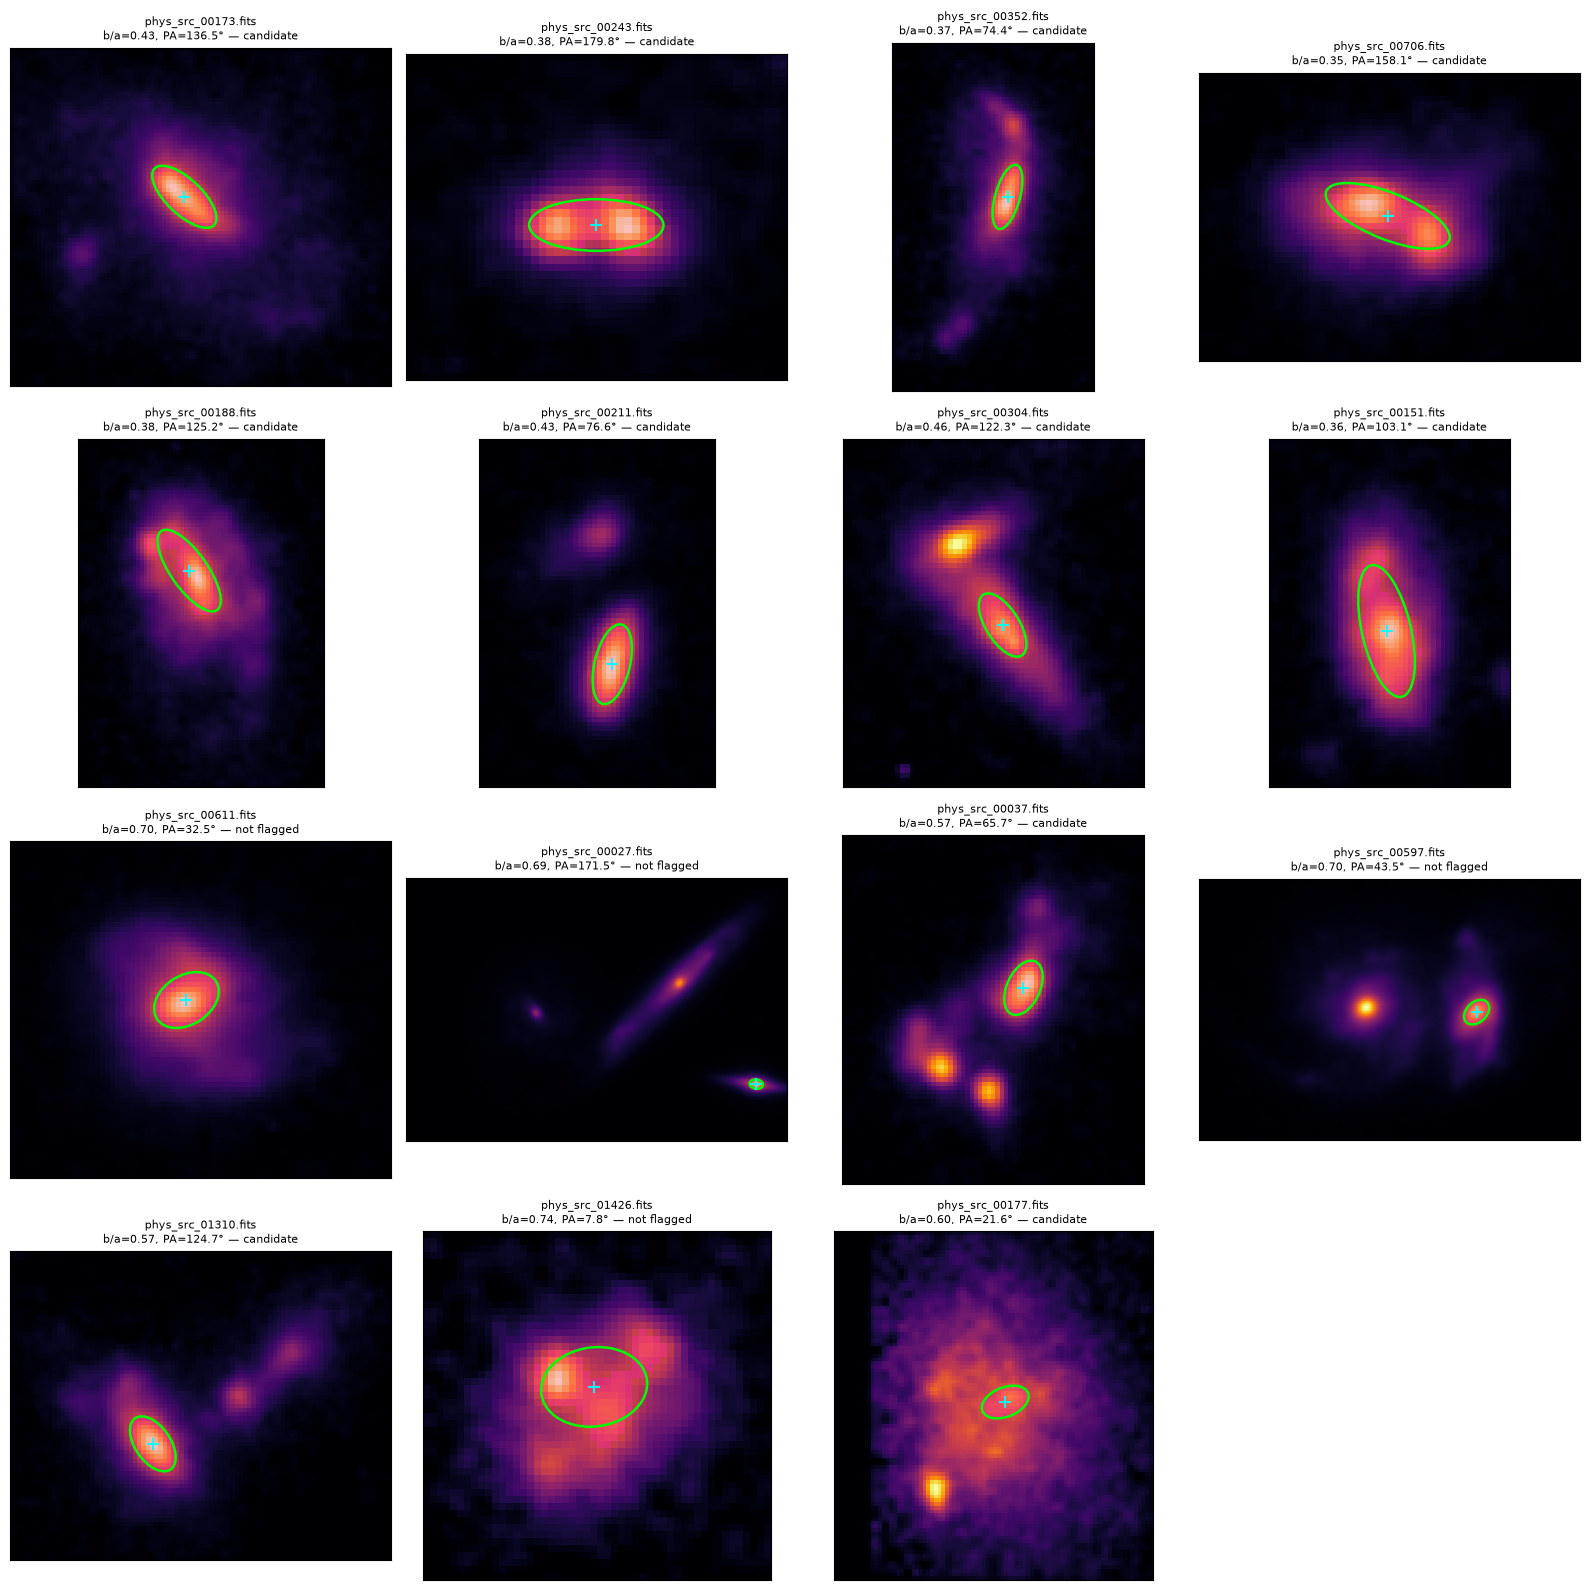

In [20]:
n_images = len(images)
columns = 4
rows = (n_images + columns - 1) // columns

fig, axes = plt.subplots(
    rows, columns,
    figsize=(4 * columns, 4 * rows),
    squeeze=False,
)

for i, ax in enumerate(axes.flat):
    if i >= n_images:
        ax.axis("off")
        continue

    conv = convs[i]
    record = ellipse_records[i]

    ax.imshow(
        conv,
        origin="lower",
        cmap="inferno",
        vmin=0,
        vmax=np.nanmax(conv),
    )

    mask = record["mask"]
    if mask.any():
        ax.imshow(
            np.where(mask, 1, np.nan),
            origin="lower",
            cmap="spring",
            alpha=0.25,
        )

    if "a_fit" in record:
        ax.add_patch(
            Ellipse(
                (record["x_c"], record["y_c"]),
                width=2 * record["a_fit"],
                height=2 * record["b_fit"],
                angle=record["angle_deg"],
                edgecolor="lime",
                facecolor="none",
                linewidth=1.8,
            )
        )
        ax.plot(
            record["x_c"], record["y_c"], "+",
            color="cyan", markersize=8, markeredgewidth=1.3,
        )

        status = "candidate" if record["suspected_barred"] else "not flagged"
        ax.set_title(
            f"{images[i].split('/')[-1]}\n"
            f"b/a={record['q']:.2f}, PA={record['angle_deg']:.1f}° — {status}",
            fontsize=8,
        )
    else:
        ax.set_title(f"{images[i].split('/')[-1]}\nNo usable ellipse", fontsize=8)

    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()